First 5 Rows of Dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Dataset Shape:
(20640, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 n

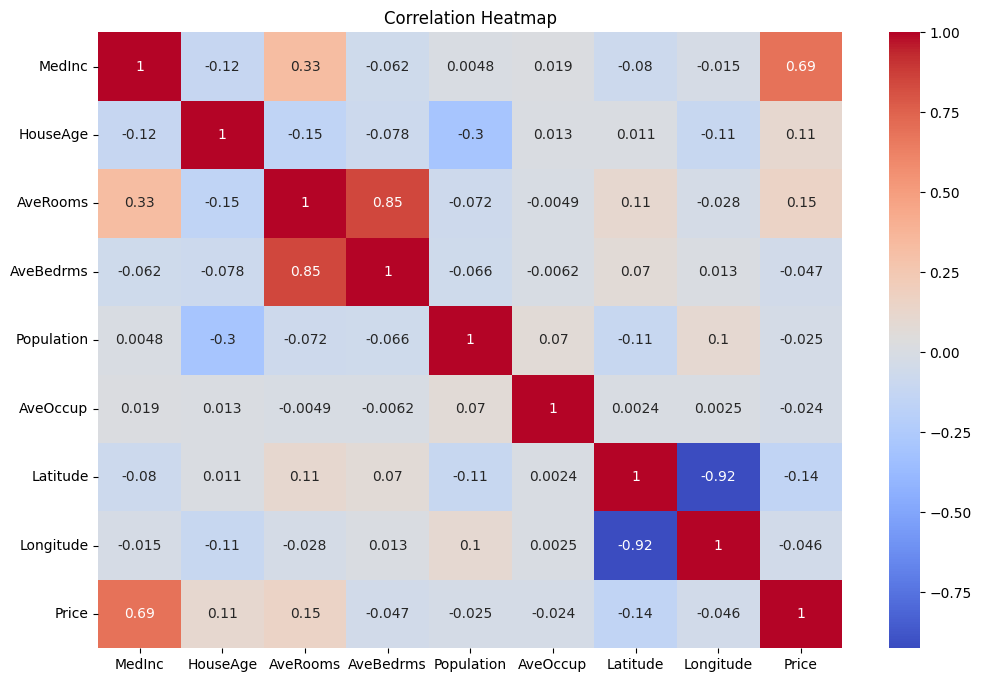

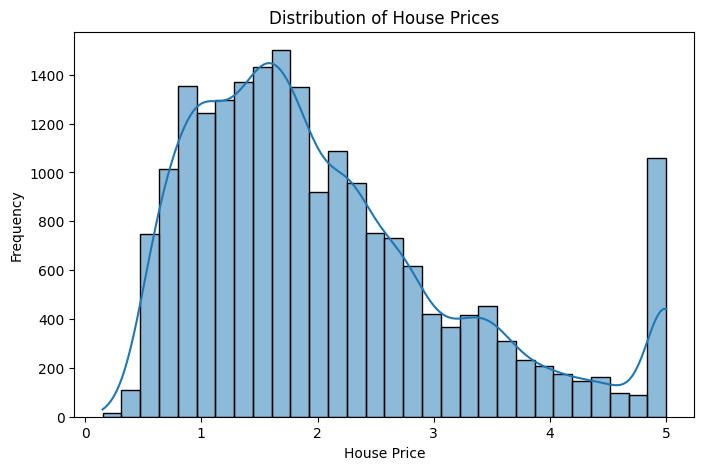


Selected Features:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

Training Data Shape: (16512, 8)
Testing Data Shape: (4128, 8)

Linear Regression Model Training Completed

First 10 Predictions:
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]

LINEAR REGRESSION EVALUATION
--------------------------------
Mean Absolute Error: 0.5332001304956557
Mean Squared Error: 0.5558915986952435
Root Mean Squared Error: 0.7455813830127758
R2 Score: 0.5757877060324514

Actual vs Predicted Values:
    Actual  Predicted
0  0.47700   0.719123
1  0.45800   1.764017
2  5.00001   2.709659
3  2.18600   2.838926
4  2.78000   2.604657
5  1.58700   2.011754
6  1.98200   2.645500
7  1.57500   2.168755
8  3.40000   2.740746
9  4.46600   3.915615


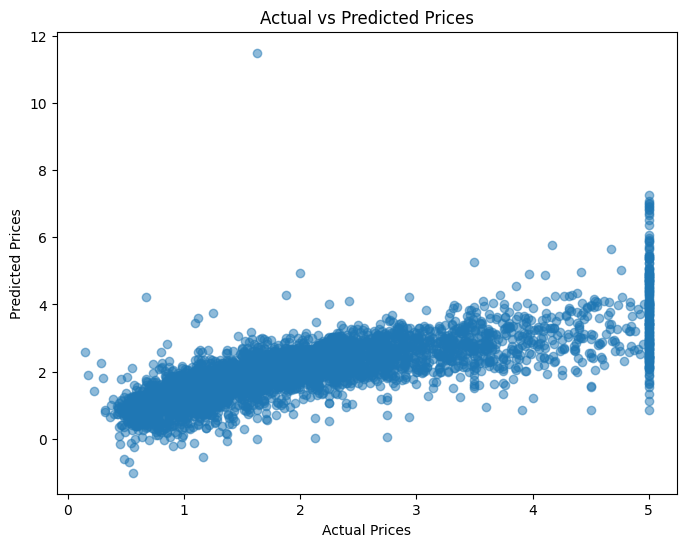


RANDOM FOREST REGRESSOR EVALUATION
--------------------------------------
Mean Absolute Error: 0.32754256845930246
Mean Squared Error: 0.2553684927247781
Root Mean Squared Error: 0.5053399773665033
R2 Score: 0.8051230593157366

Feature Importance:
      Feature  Importance
0      MedInc    0.524871
5    AveOccup    0.138443
6    Latitude    0.088936
7   Longitude    0.088629
1    HouseAge    0.054593
2    AveRooms    0.044272
4  Population    0.030650
3   AveBedrms    0.029606


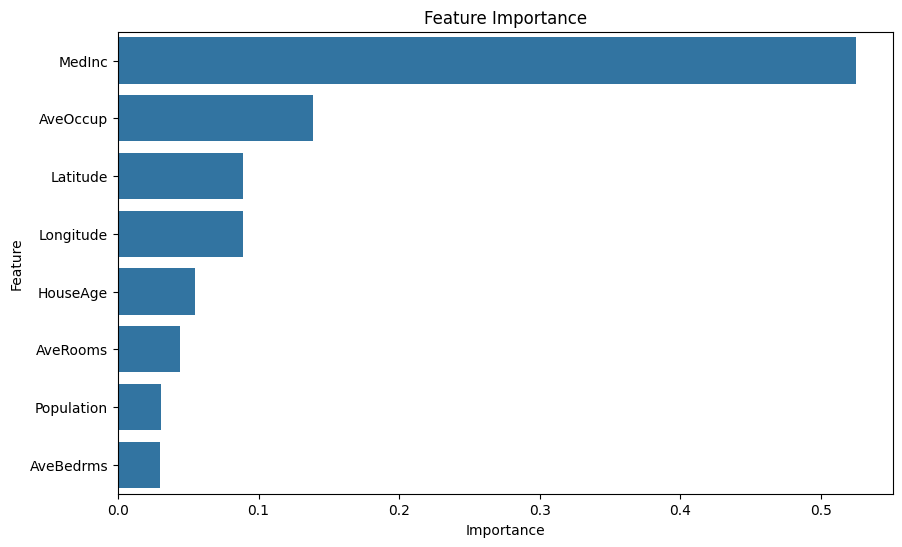


CONCLUSION

1. Loaded and explored the California Housing dataset.

2. Performed Exploratory Data Analysis (EDA).

3. Selected features and target variable.

4. Split dataset into training and testing sets.

5. Trained Linear Regression and Random Forest models.

6. Evaluated models using:
   - MAE
   - MSE
   - RMSE
   - R2 Score

7. Random Forest Regressor performed better
   compared to Linear Regression.

8. Successfully completed Regression-based
   Machine Learning prediction task.



In [ ]:

# MACHINE LEARNING INTERNSHIP TASK
# HOUSE PRICE PREDICTION USING REGRESSION



# STEP 1: IMPORT LIBRARIES


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# STEP 2: LOAD DATASET


# Load California Housing Dataset
housing = fetch_california_housing()

# Convert to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add target column
df['Price'] = housing.target

# Display first 5 rows
print("First 5 Rows of Dataset:")
print(df.head())


# STEP 3: DATASET INFORMATION


print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())


# STEP 4: CHECK MISSING VALUES


print("\nMissing Values:")
print(df.isnull().sum())


# STEP 5: EXPLORATORY DATA ANALYSIS (EDA)


# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Distribution of House Prices
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('House Price')
plt.ylabel('Frequency')
plt.show()


# STEP 6: FEATURE SELECTION


# Features (Independent Variables)
X = df.drop('Price', axis=1)

# Target Variable
y = df['Price']

print("\nSelected Features:")
print(X.columns)


# STEP 7: TRAIN-TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


# STEP 8: MODEL TRAINING - LINEAR REGRESSION


lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

print("\nLinear Regression Model Training Completed")


# STEP 9: PREDICTIONS


lr_predictions = lr_model.predict(X_test)

print("\nFirst 10 Predictions:")
print(lr_predictions[:10])


# STEP 10: MODEL EVALUATION


mae = mean_absolute_error(y_test, lr_predictions)
mse = mean_squared_error(y_test, lr_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, lr_predictions)

print("\nLINEAR REGRESSION EVALUATION")
print("--------------------------------")
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)


# STEP 11: ACTUAL VS PREDICTED VALUES


comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': lr_predictions
})

print("\nActual vs Predicted Values:")
print(comparison.head(10))


# STEP 12: VISUALIZATION OF PREDICTIONS


plt.figure(figsize=(8,6))
plt.scatter(y_test, lr_predictions, alpha=0.5)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()


# STEP 13: RANDOM FOREST REGRESSOR (BONUS)


rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train Random Forest Model
rf_model.fit(X_train, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test)

# Evaluation
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

print("\nRANDOM FOREST REGRESSOR EVALUATION")
print("--------------------------------------")
print("Mean Absolute Error:", rf_mae)
print("Mean Squared Error:", rf_mse)
print("Root Mean Squared Error:", rf_rmse)
print("R2 Score:", rf_r2)


# STEP 14: FEATURE IMPORTANCE


importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(importance)

# Plot Feature Importance
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Feature Importance')
plt.show()


# STEP 15: CONCLUSION


print("\n=================================================")
print("CONCLUSION")
print("=================================================")

print("""
1. Loaded and explored the California Housing dataset.

2. Performed Exploratory Data Analysis (EDA).

3. Selected features and target variable.

4. Split dataset into training and testing sets.

5. Trained Linear Regression and Random Forest models.

6. Evaluated models using:
   - MAE
   - MSE
   - RMSE
   - R2 Score

7. Random Forest Regressor performed better
   compared to Linear Regression.

8. Successfully completed Regression-based
   Machine Learning prediction task.
""")